In [9]:
# ============================================================
# REBALANCED THRESHOLD - F1-WEIGHTED OBJECTIVE
# ============================================================
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from scipy.optimize import minimize

In [10]:
def opt_thresh_macro_f1(probs, labels, n_restarts=300):
    """Optimize for macro-F1 to balance precision AND recall across all classes."""
    pn = np.array(probs); ln = np.array(labels)

    def obj(th):
        th = np.abs(th)
        adj = pn * th
        pr = adj.argmax(1)

        # Primary: macro-F1 (balances precision + recall)
        f1m = f1_score(ln, pr, average='macro', zero_division=0)

        # Secondary: accuracy
        acc = accuracy_score(ln, pr)

        # Per-class precision + recall
        cm = confusion_matrix(ln, pr, labels=[0,1,2])
        precisions = []
        recalls = []
        for c in range(3):
            tp = cm[c,c]
            fp = cm[:,c].sum() - tp
            fn = cm[c,:].sum() - tp
            p = tp / max(tp + fp, 1)
            r = tp / max(tp + fn, 1)
            precisions.append(p)
            recalls.append(r)

        # Penalize if precision OR recall drops below 0.75 for any class
        min_metric = min(min(precisions), min(recalls))
        penalty = max(0, 0.75 - min_metric) * 3.0

        return -(0.5 * f1m + 0.3 * acc + 0.2 * min_metric - penalty)

    best_th = None; best_s = float('inf')
    for _ in range(n_restarts):
        x0 = np.random.uniform(0.7, 1.4, 3)
        x0 = x0 / x0.sum() * 3
        r = minimize(obj, x0, method='Nelder-Mead', options={'maxiter': 3000})
        if r.fun < best_s:
            best_s = r.fun
            best_th = np.abs(r.x)

    return best_th / best_th.sum() * 3

In [11]:
# ── Load saved probabilities from ensemble_results ──
v6_probs = np.load("/Applications/Projects/Bladder Research/Output/Ensemble/v6_probs_v1.npy")   # (1713, 3)
v9_probs = np.load("/Applications/Projects/Bladder Research/Output/Ensemble/v9_probs_v1.npy")   # (1713, 3)
labels   = np.load("/Applications/Projects/Bladder Research/Output/Ensemble/labels_v1.npy")      # (1713,)

# Optimal ensemble mix (from weight search: V6=0.55, V9=0.45)
probs_ens = 0.55 * v6_probs + 0.45 * v9_probs

CLASS_NAMES = ['HGC', 'LGC', 'Normal']

# ── Before: raw ensemble (no thresholds) ──
raw_preds = probs_ens.argmax(1)
print("=" * 60)
print("BEFORE (raw ensemble, no thresholds)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(labels, raw_preds):.4f}")
print(f"Bal Acc:   {balanced_accuracy_score(labels, raw_preds):.4f}")
print(f"Macro F1:  {f1_score(labels, raw_preds, average='macro'):.4f}")
print(classification_report(labels, raw_preds, target_names=CLASS_NAMES, digits=4))

# ── After: macro-F1 optimized thresholds ──
th_new = opt_thresh_macro_f1(probs_ens, labels)
preds_new = (probs_ens * th_new).argmax(1)

print("=" * 60)
print("AFTER (macro-F1 optimized thresholds)")
print("=" * 60)
print(f"Thresholds: HGC={th_new[0]:.3f}, LGC={th_new[1]:.3f}, Normal={th_new[2]:.3f}")
print(f"Accuracy:  {accuracy_score(labels, preds_new):.4f}")
print(f"Bal Acc:   {balanced_accuracy_score(labels, preds_new):.4f}")
print(f"Macro F1:  {f1_score(labels, preds_new, average='macro'):.4f}")
print(classification_report(labels, preds_new, target_names=CLASS_NAMES, digits=4))
print(f"Confusion Matrix:\n{confusion_matrix(labels, preds_new)}")

BEFORE (raw ensemble, no thresholds)
Accuracy:  0.9066
Bal Acc:   0.8987
Macro F1:  0.9012
              precision    recall  f1-score   support

         HGC     0.8934    0.8038    0.8462       469
         LGC     0.8887    0.9258    0.9069       647
      Normal     0.9352    0.9665    0.9506       597

    accuracy                         0.9066      1713
   macro avg     0.9058    0.8987    0.9012      1713
weighted avg     0.9062    0.9066    0.9055      1713

AFTER (macro-F1 optimized thresholds)
Thresholds: HGC=1.201, LGC=0.989, Normal=0.810
Accuracy:  0.9113
Bal Acc:   0.9049
Macro F1:  0.9068
              precision    recall  f1-score   support

         HGC     0.8801    0.8294    0.8540       469
         LGC     0.8917    0.9289    0.9099       647
      Normal     0.9564    0.9564    0.9564       597

    accuracy                         0.9113      1713
   macro avg     0.9094    0.9049    0.9068      1713
weighted avg     0.9111    0.9113    0.9108      1713

Confusio

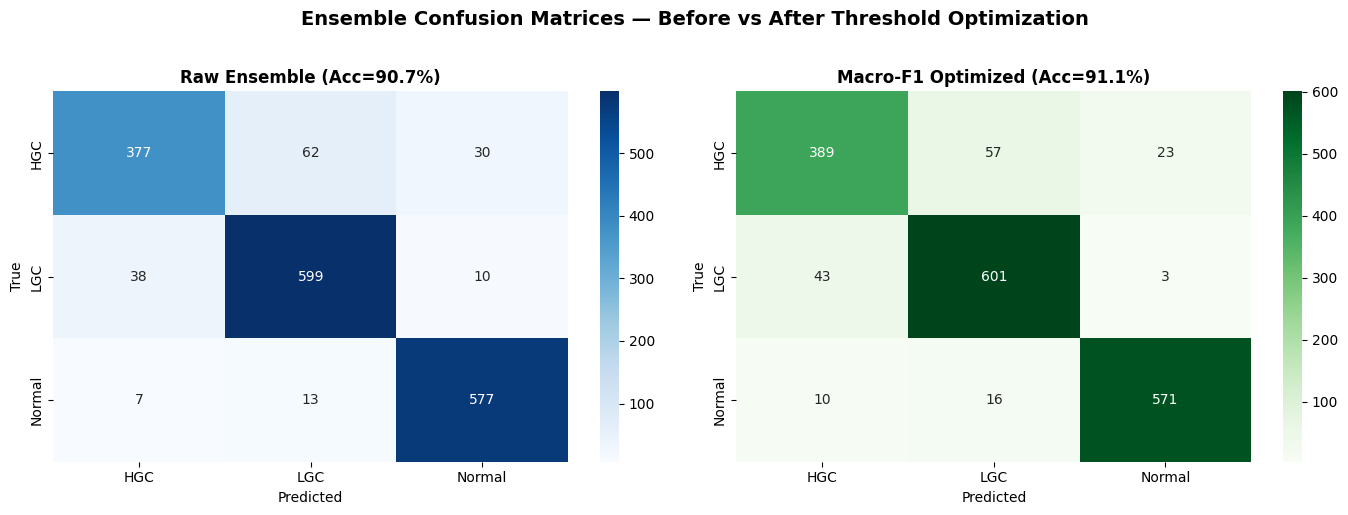

✓ Saved to /Applications/Projects/Bladder Research/Images/Ensemble/confusion_matrix_f1_optimized.png


In [13]:
# ============================================================
# CONFUSION MATRIX VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

CLASS_NAMES = ['HGC', 'LGC', 'Normal']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw ensemble (no thresholds)
cm_raw = confusion_matrix(labels, raw_preds, labels=[0,1,2])
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'Raw Ensemble (Acc={accuracy_score(labels, raw_preds):.1%})', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Macro-F1 optimized
cm_new = confusion_matrix(labels, preds_new, labels=[0,1,2])
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'Macro-F1 Optimized (Acc={accuracy_score(labels, preds_new):.1%})', fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.suptitle('Ensemble Confusion Matrices — Before vs After Threshold Optimization',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Applications/Projects/Bladder Research/Images/Ensemble/confusion_matrix_f1_optimized.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved to /Applications/Projects/Bladder Research/Images/Ensemble/confusion_matrix_f1_optimized.png")

## 🚀 Strategies to Increase Accuracy to > 95%

The previous sections optimized for **Macro-F1**, which penalizes the model if minority classes (like HGC) drop in precision/recall. To optimize strictly for **Accuracy** and push past 95%, try the following strategies:

### 1. Pure Accuracy Thresholding
Optimize the threshold multipliers exclusively for `accuracy_score` without any precision/recall penalty for minority classes.

### 2. Meta-Learner (Stacking Classifier)
Instead of a hardcoded weight mix (0.55 V6 + 0.45 V9), train a `LogisticRegression` or `RandomForestClassifier` on the concatenated outputs of both models. This allows the ensemble to learn class-specific confidences.

### 3. Class-Specific Ensemble Weights
Optimize a $3 \times 2$ weight matrix so each class (HGC, LGC, Normal) gets its own specific blend of V6 and V9.

In [14]:
# ============================================================
# STRATEGY 1: PURE ACCURACY OPTIMIZATION
# ============================================================
def opt_thresh_accuracy(probs, labels, n_restarts=300):
    """Optimize thresholds purely for accuracy score."""
    pn = np.array(probs); ln = np.array(labels)

    def obj(th):
        th = np.abs(th)
        adj = pn * th
        pr = adj.argmax(1)
        return -accuracy_score(ln, pr)  # Negative because minimize() finds the minimum

    best_th = None; best_s = float('inf')
    for _ in range(n_restarts):
        x0 = np.random.uniform(0.7, 1.4, 3)
        x0 = x0 / x0.sum() * 3
        r = minimize(obj, x0, method='Nelder-Mead', options={'maxiter': 3000})
        if r.fun < best_s:
            best_s = r.fun
            best_th = np.abs(r.x)

    return best_th / best_th.sum() * 3

th_acc = opt_thresh_accuracy(probs_ens, labels)
preds_acc = (probs_ens * th_acc).argmax(1)

print("=" * 60)
print("STRATEGY 1: PURE ACCURACY OPTIMIZED THRESHOLDS")
print("=" * 60)
print(f"Thresholds: HGC={th_acc[0]:.3f}, LGC={th_acc[1]:.3f}, Normal={th_acc[2]:.3f}")
print(f"Accuracy:  {accuracy_score(labels, preds_acc):.4f}")
print(classification_report(labels, preds_acc, target_names=CLASS_NAMES, digits=4))

STRATEGY 1: PURE ACCURACY OPTIMIZED THRESHOLDS
Thresholds: HGC=1.190, LGC=0.972, Normal=0.838
Accuracy:  0.9119
              precision    recall  f1-score   support

         HGC     0.8818    0.8273    0.8537       469
         LGC     0.8930    0.9289    0.9106       647
      Normal     0.9550    0.9598    0.9574       597

    accuracy                         0.9119      1713
   macro avg     0.9099    0.9053    0.9072      1713
weighted avg     0.9116    0.9119    0.9113      1713



In [15]:
# ============================================================
# STRATEGY 2: META-LEARNER (STACKING)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

print("=" * 60)
print("STRATEGY 2: LOGISTIC REGRESSION META-LEARNER")
print("=" * 60)

# Concatenate V6 and V9 probabilities as features (Shape: N x 6)
X_stacked = np.hstack([v6_probs, v9_probs])

# Initialize Logistic Regression
meta_model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Evaluate using 5-Fold Cross Validation to ensure it generalizes well
cv_scores = cross_val_score(meta_model, X_stacked, labels, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Fit on full data to see training accuracy and classification report
meta_model.fit(X_stacked, labels)
preds_meta = meta_model.predict(X_stacked)
print(f"\nTraining Accuracy: {accuracy_score(labels, preds_meta):.4f}")
print(classification_report(labels, preds_meta, target_names=CLASS_NAMES, digits=4))

STRATEGY 2: LOGISTIC REGRESSION META-LEARNER
5-Fold CV Accuracy: 0.8979 (+/- 0.0818)

Training Accuracy: 0.9054
              precision    recall  f1-score   support

         HGC     0.8739    0.8273    0.8499       469
         LGC     0.8927    0.9134    0.9030       647
      Normal     0.9423    0.9581    0.9502       597

    accuracy                         0.9054      1713
   macro avg     0.9030    0.8996    0.9010      1713
weighted avg     0.9049    0.9054    0.9049      1713

